### Monte Carlo Simulation of PMS Customer Retention

Traditional financial models rely on deterministic forecasting as they use fixed point estimates (e.g., assuming exactly 50% retention and exactly ₱12,000 Average Order Value) to calculate a single Return on Investment (ROI). While useful for establishing base cases, deterministic models fail to account for the chaotic, unpredictable nature of real-world consumer behavior and operational cost inflation.

To rigorously validate the financial durability of the ToyotaCares program and definitively mitigate downside risk, a stochastic modeling approach was utilized via a Monte Carlo Simulation.

#### What is a Monte Carlo Simulation?
A Monte Carlo simulation is a computational algorithm that relies on repeated random sampling to obtain numerical results. Instead of calculating one static future, the computer runs millions of possibilities that it creates millions of "alternate realities" to calculate the statistical probability of different outcomes.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [12]:
np.random.seed(42)

n_simulations = 1000000

In [13]:
# Retention Rate: Normal distribution. Mean = 65%, Std Dev = 10%. 
# We use np.clip to ensure it never drops below the 15% baseline or exceeds 95%.
retention_rates = np.random.normal(loc=0.65, scale=0.10, size=n_simulations)
retention_rates = np.clip(retention_rates, 0.15, 0.95)

# AOV: Normal distribution. Mean = ₱16,000, Std Dev = ₱3,000.
aovs = np.random.normal(loc=16000, scale=3000, size=n_simulations)

# OpEx Buffer: Uniform distribution. We assume costs will inflate anywhere from 10% to 30%.
opex_buffers = np.random.uniform(low=1.10, high=1.30, size=n_simulations)

# Fixed Capacity & Cost Baseline
total_capacity_slots = 2002 
base_monthly_opex = 824550 
gross_margin = 0.50

In [14]:
monthly_cars = total_capacity_slots * retention_rates
gross_revenue = monthly_cars * aovs
gross_profit = gross_revenue * gross_margin

actual_opex = base_monthly_opex * opex_buffers
net_profit = gross_profit - actual_opex

# ROI Calculation
roi_array = (net_profit / actual_opex) * 100

In [15]:
median_roi = np.median(roi_array)
p05_roi = np.percentile(roi_array, 5)   # 95% of the time, ROI is better than this
p95_roi = np.percentile(roi_array, 95)  # 5% of the time, ROI is better than this
prob_positive = np.mean(roi_array > 0) * 100

In [16]:
print(f"Median ROI: {median_roi:.0f}%")
print(f"90% Confidence Interval: [{p05_roi:.0f}%, {p95_roi:.0f}%]")
print(f"Probability of Positive ROI: {prob_positive:.2f}%")

Median ROI: 938%
90% Confidence Interval: [552%, 1413%]
Probability of Positive ROI: 100.00%


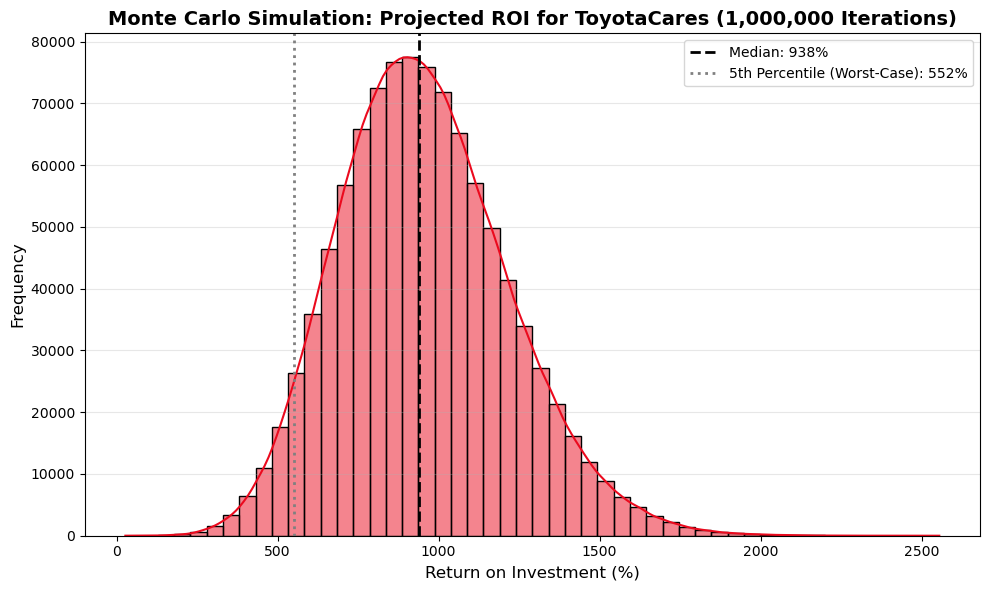

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(roi_array, bins=50, kde=True, color='#eb0a1e') # Toyota Red
plt.axvline(median_roi, color='black', linestyle='dashed', linewidth=2, label=f'Median: {median_roi:.0f}%')
plt.axvline(p05_roi, color='gray', linestyle='dotted', linewidth=2, label=f'5th Percentile (Worst-Case): {p05_roi:.0f}%')

plt.title('Monte Carlo Simulation: Projected ROI for ToyotaCares (1,000,000 Iterations)', fontsize=14, fontweight='bold')
plt.xlabel('Return on Investment (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()